# Mini Equations — Experiment Report

*Trigonometric equality proving on the HyperTree Proof Search benchmark
(22 identities), across three strategy families: `baseline`, `guided`, and
`step_by_step`.*

**TL;DR.** Across **17 baseline**, **10 guided**, and
**18 step-by-step** curated runs:

- **Step-by-step is the only strategy that reaches 22/22** — at
  \$0.53, well below the cost of the best
  baseline.
- **Baseline and guided top out at 19/22.** Best baseline run:
  \$1.75. Best guided run:
  \$3.05 — a clear premium for the same coverage.
- **Saturating baseline with more budget does not close the gap.** Even with
  a 2.5× cost multiplier, baseline caps at 20/22. The missing two equations
  (benchmarks 018 and 019, both *derived product identities*) only fall to
  step-by-step. The bottleneck is **strategy, not budget**.

### Contents

1. [Methodology](#methodology)
2. [Baseline](#baseline)
3. [Guided](#guided)
4. [Step-by-step](#step-by-step)
5. [Three-way comparison](#three-way-comparison)
6. [Saturating the baseline](#saturating-the-baseline)
7. [Common failure patterns by model](#common-failure-patterns-by-model)
8. [Why step-by-step works](#why-step-by-step-works)


In [1]:
from pathlib import Path
import sys

import pandas as pd
from IPython.display import HTML, SVG, display

for candidate in [Path.cwd(), *Path.cwd().parents]:
    report_dir = candidate / 'examples' / 'mini_eqns' / 'experiments' / 'report'
    if report_dir.exists():
        REPORT_DIR = report_dir
        break
else:
    raise FileNotFoundError(
        'Could not locate examples/mini_eqns/experiments/report from the '
        'current working directory.'
    )

if str(REPORT_DIR) not in sys.path:
    sys.path.insert(0, str(REPORT_DIR))

import report_utils as ru

paths = ru.find_report_paths(Path.cwd())
benchmarks = ru.load_benchmarks(paths.benchmark_file)
runs = ru.load_report_runs(paths.report_root)
inventory = ru.build_experiment_inventory(runs)
best_configs = ru.select_best_configs(inventory)
best_baseline_name = str(best_configs.loc[best_configs['family'] == 'baseline', 'experiment_name'].iloc[0])
best_guided_name = str(best_configs.loc[best_configs['family'] == 'guided', 'experiment_name'].iloc[0])
best_step_name = str(best_configs.loc[best_configs['family'] == 'step_by_step', 'experiment_name'].iloc[0])
step_advantage = ru.build_step_advantage_table(
    runs, benchmarks, best_baseline_name, best_guided_name, best_step_name
)

pd.set_option('display.max_colwidth', 120)
display(HTML('''
<style>
.jp-RenderedMarkdown {
  max-width: 920px;
  margin: 0 auto;
  line-height: 1.55;
}
.jp-RenderedMarkdown h1 { font-size: 1.8rem; margin: 0.15rem 0 0.55rem 0; }
.jp-RenderedMarkdown h2 { font-size: 1.25rem; margin: 1.4rem 0 0.4rem 0; border-bottom: 1px solid #e5e7eb; padding-bottom: 0.2rem; }
.jp-RenderedMarkdown h3 { font-size: 1.02rem; margin: 0.95rem 0 0.28rem 0; }
.jp-RenderedMarkdown p, .jp-RenderedMarkdown li { font-size: 0.97rem; }
.jp-RenderedMarkdown em { color: #475569; }
.table-container, .strategy-wrap { max-width: 920px; margin: 0 auto; }
.report-simple-table, .strategy-matrix {
  border-collapse: collapse;
  width: 100%;
  font-size: 13px;
  margin: 0.35rem 0 0.8rem 0;
}
.report-simple-table th, .report-simple-table td,
.strategy-matrix th, .strategy-matrix td {
  border-bottom: 1px solid #e5e7eb;
  padding: 8px 10px;
  text-align: left;
  vertical-align: middle;
}
.report-simple-table th, .strategy-matrix th {
  background: #f8fafc;
  font-weight: 600;
}
.report-simple-table tr:nth-child(even) td { background: #fbfdff; }
.strategy-matrix td.empty { color: #94a3b8; text-align: center; }
.matrix-card {
  border-radius: 10px;
  padding: 10px 10px 8px 10px;
  min-width: 108px;
  box-shadow: inset 0 0 0 1px rgba(255,255,255,.45);
}
.matrix-card .solve { font-size: 16px; font-weight: 700; line-height: 1.1; }
.matrix-card .cost { font-size: 12px; margin-top: 4px; }
.matrix-card .label { font-size: 11px; margin-top: 6px; opacity: .82; }
</style>
'''))

<a id="methodology"></a>
## Methodology

All configuration metadata is recovered from `experiment.yaml`, while solved
counts and cost come from `results_summary.csv`. The summary matrices show
solved equations out of 22, total run cost, and a short experiment label.

Two legacy baseline runs use reasoning effort `None`
(`baseline_experiment_1` and `baseline_experiment_6`); that label is carried
explicitly in this report rather than being treated as missing metadata.

**Cost metering.** All dollar amounts in this report are actual API token
counts multiplied by the official per-model OpenAI prices for the gpt-5.4
family (gpt-5.4: \$2.50/\$0.25/\$15 per million input/cached/output
tokens; gpt-5.4-mini: \$0.75/\$0.075/\$4.50). Delphyne's pricing table
originally predated this model family and its `pricing="auto"` fallback
silently billed gpt-5.4 models at gpt-5 rates (under-billing gpt-5.4 by
1.5× and over-billing gpt-5.4-mini by 2.2×); the table has since been
fixed upstream. Runs recorded before the fix are *re-metered* exactly from
their recorded token counts when they used a single model
(`price_meter == "official (re-metered)"` in the inventory); a handful of
legacy sketch runs that mixed models keep their as-recorded prices and are
flagged `legacy`.

The step-by-step family contains three variants. Runs 1–9 used an early
revision in which the planner produced a *proof sketch* in a custom text
format; they are kept for comparison. Runs 10–12 use the flat
**draft-and-repair** revision, in which the planner writes a complete proof
directly in the checker's own YAML format and a repair model only fixes the
steps that fail verification. Runs 13 and later add **budget escalation**:
a cheap tier (low-effort draft, `gpt-5.4-mini` repairs, capped in both
requests and dollars) attempts every problem first, and only the problems
it cannot solve escalate to the strong configuration.

**Re-verification.** After the metering fix, the historical best baseline
and guided configurations were re-run from scratch with runtime-correct
prices (`baseline_experiment_14`,
`guided_experiment_23`). The fresh runs solved
19/22 for \$2.41
and 19/22 for \$3.21,
against 19/22 for
\$1.75 and 19/22 for
\$3.05 from the re-metered historical runs —
re-metered and runtime-metered prices are mutually consistent, with the
residual differences attributable to sampling variance.


<a id="baseline"></a>
## Baseline

A modest amount of forced reasoning helps standard `gpt-5.4`, but pushing
harder stops paying off.

- For `gpt-5.4`, `low` and `medium` tie at **19/22**, and `low` is the better
  choice — \$2.41 vs
  \$2.23.
- More reasoning is not free: `high` falls to **18/22**, `xhigh` to **17/22**
  at \$4.76, and `None` to **15/22**.
- `gpt-5.4-mini` is dominated (only **10/22** at `low` for
  \$1.34); `gpt-5.4-nano` is the better
  lightweight option, reaching **17/22** at `high`.

*Matrix caption: rows are executor model, columns are reasoning effort. Each
cell shows solved count and total cost.*


In [2]:
display(HTML(ru.render_strategy_matrix_html(inventory, 'baseline')))

Model,None,low,medium,high,xhigh
GPT-5.4,15 / 22$2.67B1,19 / 22$2.41B14,19 / 22$2.23B3,18 / 22$2.76B4,17 / 22$4.76B5
GPT-5.4 mini,11 / 22$1.50B6,10 / 22$1.34B7,14 / 22$1.53B8,10 / 22$1.78B9,—
GPT-5.4 nano,—,9 / 22$0.39B10,16 / 22$0.34B11,17 / 22$0.34B12,16 / 22$0.82B13


<a id="guided"></a>
## Guided

Guided search is competitive but does not move the frontier.

- On `gpt-5.4`, guided reaches **18/22**, **19/22**, **19/22** at
  `low` / `medium` / `high` — essentially tied with baseline.
- The match comes with a
  \$0.24–\$1.31
  premium per run, depending on effort level.
- Guided does not rescue `gpt-5.4-mini`: solved count stays flat at
  **12/22** while cost climbs to \$3.78 at
  `high`.


In [3]:
display(HTML(ru.render_strategy_matrix_html(inventory, 'guided')))

Model,low,medium,high
GPT-5.4,18 / 22$2.65G14,19 / 22$3.05G15,19 / 22$4.08G16
GPT-5.4 mini,12 / 22$1.41G17,12 / 22$2.06G18,12 / 22$3.78G19
GPT-5.4 nano,11 / 22$0.43G20,14 / 22$0.44G21,16 / 22$0.64G22


<a id="step-by-step"></a>
## Step-by-Step (Draft & Repair, with Budget Escalation)

The step-by-step runs are the strongest results in the report and already
change the overall conclusion.

- The flat draft-and-repair strategy solves **22/22 in every replica**
  (`step_by_step_experiment_10`, `step_by_step_experiment_12`, `step_by_step_experiment_11`) for
  \$0.65–\$0.77
  — full coverage at well under half the cost of the best baseline.
- In the best flat run, **20 of the 22 equations are
  proved by the single draft call**, with zero repair calls; only the two
  product identities (018, 019) need repair rounds.
- The **budget-escalation** runs
  (`step_by_step_experiment_14`, `step_by_step_experiment_16`, `step_by_step_experiment_17`, `step_by_step_experiment_15`, `step_by_step_experiment_18`, `step_by_step_experiment_13`) keep 22/22 while
  pushing total cost to
  \$0.53–\$0.82:
  a cheap tier (low-effort drafts, `gpt-5.4-mini` repairs) settles
  most equations for under a cent each, and only the hard tail pays for
  the strong configuration. The remaining run-to-run spread comes from
  the heavy-tailed reasoning-token usage of the escalated problems.
- The earlier sketch-based variant (runs 1–9) topped out at **22/22** for
  \$1.92
  (21–22/22 across `gpt-5.4` / `low` replicas for
  \$1.92–\$2.27),
  so the redesign improved cost substantially while keeping full coverage.
- Under the old variant, lighter executors held up well: both `gpt-5.4-mini`
  and `gpt-5.4-nano` at `low` reached **21/22** for around
  \$1.57–\$1.54
  (as-recorded legacy prices; these runs mixed models and cannot be
  re-metered exactly).


In [4]:
display(HTML(ru.render_step_by_step_matrix_html(inventory)))

Step model,None,low,medium
GPT-5.4,—,"21-22 / 22$0.53-$2.2712 runs: S1, S10, S11, S12, S13, S14, S15, S16, S17, S18, S2, S3",—
GPT-5.4 mini,16 / 22$2.20S5,21 / 22$1.57S4,19 / 22$2.07S6
GPT-5.4 nano,12 / 22$2.79S7,21 / 22$1.54S8,21 / 22$2.14S9


<a id="three-way-comparison"></a>
## Three-Way Comparison

The strongest current runs are **baseline_experiment_2**,
**guided_experiment_15**, and **step_by_step_experiment_14**.
This is the headline result: baseline and guided top out at **19/22**, with
guided paying a premium, while step-by-step reaches full coverage at the
lowest cost of the three.

*Leaderboard below — sorted by solved count (descending), then by cost
(ascending).*


In [5]:
leaderboard = inventory.loc[
    inventory['experiment_name'].isin([best_baseline_name, best_guided_name, best_step_name]),
    ['family', 'experiment_name', 'model_name', 'reasoning_effort',
     'sketch_model_name', 'sketch_reasoning_effort', 'solved', 'total_cost']
].copy()
leaderboard['strategy'] = leaderboard['family'].map({
    'baseline': 'Baseline',
    'guided': 'Guided',
    'step_by_step': 'Step-by-step',
})
leaderboard['executor'] = leaderboard['model_name'].map(ru.model_label)
leaderboard['executor effort'] = leaderboard['reasoning_effort'].astype(str)
leaderboard['sketch'] = leaderboard.apply(
    lambda row: (
        f"{ru.model_label(str(row['sketch_model_name']))} / {row['sketch_reasoning_effort']}"
        if row['family'] == 'step_by_step' else '—'
    ),
    axis=1,
)
leaderboard = leaderboard[['strategy', 'experiment_name', 'executor', 'executor effort', 'sketch', 'solved', 'total_cost']]
leaderboard = leaderboard.sort_values(['solved', 'total_cost'], ascending=[False, True])
leaderboard = leaderboard.rename(columns={
    'experiment_name': 'experiment',
    'total_cost': 'total cost',
})
display(HTML(ru.render_simple_table_html(
    leaderboard,
    formatters={
        'solved': lambda value: f'{int(value)}/22',
        'total cost': ru.precise_money,
    },
)))

strategy,experiment,executor,executor effort,sketch,solved,total cost
Step-by-step,step_by_step_experiment_14,GPT-5.4,low,GPT-5.4 / medium,22/22,$0.5280
Baseline,baseline_experiment_2,GPT-5.4,low,—,19/22,$1.7483
Guided,guided_experiment_15,GPT-5.4,medium,—,19/22,$3.0480


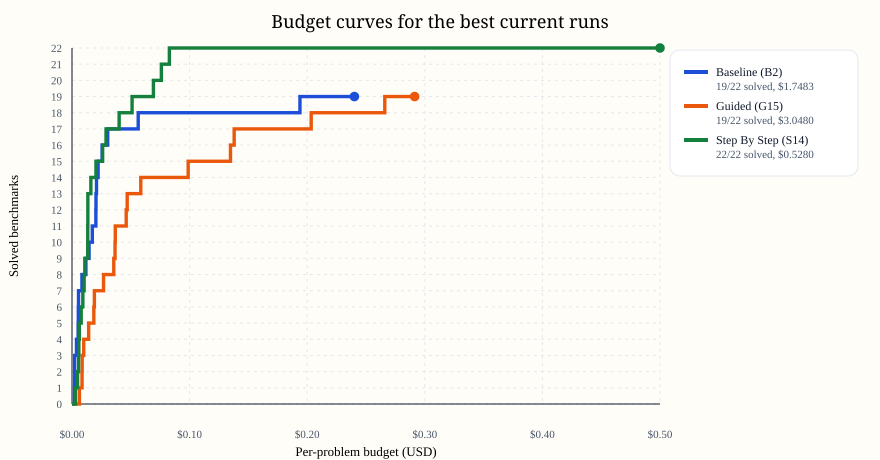

In [6]:
curves = ru.load_budget_curves(paths.report_root, [best_baseline_name, best_guided_name, best_step_name])
display(SVG(ru.render_budget_curves_svg(curves, inventory, title='Budget curves for the best current runs')))

*Budget curve: x-axis is per-equation inference cost, y-axis is cumulative
equations solved. A curve that is both to the left and above another curve
strictly dominates it.*

The plot makes the comparison easy to read:

- **Step-by-step is the only strategy that reaches 22/22.**
- It does so **at the lowest cost of any strategy**
  (\$0.53 vs \$1.75
  for the best baseline).
- **Guided matches baseline on solved count but finishes about
  \$1.30 higher.**


### Where the extra coverage comes from

The best step-by-step run solves two equations that both best baseline and
best guided miss, and gives up nothing in return. The win is a genuine
expansion of coverage, not a different trade.


In [7]:
step_only = step_advantage.loc[
    step_advantage['status'] == 'step_only',
    ['bench_name', 'equation', 'baseline', 'guided', 'step_by_step']
].copy()
step_only = step_only.rename(columns={
    'baseline': 'best baseline',
    'guided': 'best guided',
    'step_by_step': 'best step-by-step',
})
display(HTML(ru.render_simple_table_html(
    step_only,
    formatters={
        'best baseline': lambda value: 'yes' if value else 'no',
        'best guided': lambda value: 'yes' if value else 'no',
        'best step-by-step': lambda value: 'yes' if value else 'no',
    },
)))
print(f'Step regressions against the best baseline/guided runs: {int((step_advantage["status"] == "step_regression").sum())}')

bench_name,equation,best baseline,best guided,best step-by-step
018,cos(x + y)*cos(x - y) = cos(x)**2 - sin(y)**2,no,no,yes
019,sin(x + y)*sin(y - x) = cos(x)**2 - cos(y)**2,no,no,yes


Step regressions against the best baseline/guided runs: 0


<a id="saturating-the-baseline"></a>
## Saturating the Baseline

The headline question for this section: **can the baseline strategy catch up
to step-by-step simply by being given more resources?**

To test it, three new runs
(`baseline_experiment_saturate_1/2/3`) push the baseline strategy to its
limits by raising:

- `max_dollar_budget` — the per-equation spending cap, which controls how
  many request retries the strategy can afford.
- `max_feedback_cycles` — the maximum number of corrective rounds the model
  gets when the checker rejects its proof.
- `loop=True` — letting the whole strategy restart on failure, within the
  budget.

Each saturate level relaxes those limits a bit further. If the baseline gap
to step-by-step were just a budget issue, we should see it close as the
budget grows.


In [8]:
saturate_names = [
    'baseline_experiment_saturate_1',
    'baseline_experiment_saturate_2',
    'baseline_experiment_saturate_3',
]

sat_rows = []
for name in saturate_names:
    sub = runs.loc[runs['experiment_name'] == name]
    if sub.empty:
        continue
    sat_rows.append({
        'run': name.replace('baseline_experiment_', ''),
        'max feedback cycles': int(sub['configured_max_feedback_cycles'].iloc[0]),
        'max $/equation': float(sub['configured_budget'].iloc[0]),
        'solved': int(sub['success'].sum()),
        'total cost': float(sub['price'].sum()),
    })

step_best = inventory.loc[inventory['experiment_name'] == best_step_name].iloc[0]
sat_rows.append({
    'run': 'step_by_step (best)',
    'max feedback cycles': int(step_best['configured_max_feedback_cycles']) if pd.notna(step_best['configured_max_feedback_cycles']) else '—',
    'max $/equation': float(step_best['configured_budget']) if pd.notna(step_best['configured_budget']) else '—',
    'solved': int(step_best['solved']),
    'total cost': float(step_best['total_cost']),
})

saturate_table = pd.DataFrame(sat_rows)
display(HTML(ru.render_simple_table_html(
    saturate_table,
    formatters={
        'solved': lambda v: f'{int(v)}/22',
        'total cost': ru.precise_money,
        'max $/equation': lambda v: f'${v:.2f}' if isinstance(v, (int, float)) else v,
    },
)))

run,max feedback cycles,max $/equation,solved,total cost
saturate_1,30,$0.50,19/22,$3.2250
saturate_2,40,$0.75,20/22,$4.3320
saturate_3,20,$0.75,19/22,$4.5451
step_by_step (best),4,$0.50,22/22,$0.5280


**Reading the table.** Going from `saturate_1` to `saturate_2` raises the
per-equation budget from \$0.50 to \$0.75 and the feedback cycles from 30
to 40. That extra budget rescues exactly **one** more equation (from
**19/22** to **20/22**) at the cost of an extra **~\$0.74** of total spend.
`saturate_3` keeps the higher budget and runs again with
`max_feedback_cycles=20`, mostly to confirm the trend on a fresh seed.

**The verdict.** Even fully saturated, baseline tops out at **20/22** while
spending roughly **2.5×** what the best step-by-step run spends to reach
**22/22**. The two equations that survive every saturation level
(**018** and **019**, both *derived product identities*) are the same ones
step-by-step solves at lower cost. This is the strongest evidence in the
report that the bottleneck is **strategy, not budget**: handing the baseline
more retries does not buy structurally new behavior, it just lets it grind a
little longer on proofs that were already going to succeed.


<a id="common-failure-patterns-by-model"></a>
## Common Failure Patterns by Model

The artifacts do not record free-form error labels, so failures are grouped
by the identity family of the missed benchmark.

- **`gpt-5.4`** is narrow: its main weakness is *derived product identities*
  (**18/22**, **81.8%**).
- **`gpt-5.4-mini`** is broad: same weakness even sharper (**19/20**,
  **95%**), plus higher-order sine rewrites and periodicity.
- **`gpt-5.4-nano`** sits between the two — same top-two miss families,
  slightly more controlled overall.

The persistent weak spot across all three models is the more derived
identities built from multiple transformations, especially benchmarks
**018** and **019**.


In [9]:
BENCHMARK_GROUPS = {
    '001': 'phase shifts', '002': 'phase shifts', '003': 'phase shifts', '004': 'phase shifts',
    '005': 'special angles', '006': 'special angles', '007': 'special angles',
    '008': 'periodicity', '009': 'periodicity',
    '010': 'pythagorean',
    '011': 'double-angle / half-angle', '012': 'sum-product transforms', '013': 'sum-product transforms',
    '014': 'double-angle / half-angle', '015': 'double-angle / half-angle',
    '016': 'double-angle / half-angle', '017': 'double-angle / half-angle',
    '018': 'derived product identities', '019': 'derived product identities',
    '020': 'higher-order sine rewrites', '021': 'higher-order sine rewrites', '022': 'higher-order sine rewrites',
}

model_runs = runs.copy()
model_runs['analysis model'] = model_runs['model_name'].astype(str)
step_mask = model_runs['family'] == 'step_by_step'
model_runs.loc[step_mask, 'analysis model'] = model_runs.loc[step_mask, 'step_model_name'].astype(str)
model_runs['identity family'] = model_runs['bench_name'].map(BENCHMARK_GROUPS)
model_runs['failed'] = ~model_runs['success']
summary = (
    model_runs.groupby(['analysis model', 'identity family'], dropna=False)
    .agg(failures=('failed', 'sum'), total=('failed', 'size'))
    .reset_index()
)
summary['failure rate'] = summary['failures'] / summary['total']
summary = summary.sort_values(
    ['analysis model', 'failure rate', 'failures', 'identity family'],
    ascending=[True, False, False, True],
)
ranked = summary.groupby('analysis model').head(3).copy()
ranked['family'] = ranked['identity family']
ranked['evidence'] = ranked.apply(
    lambda row: f"{int(row['failures'])}/{int(row['total'])} ({row['failure rate']:.1%})",
    axis=1,
)
ranked = ranked[['analysis model', 'family', 'evidence']].rename(columns={'analysis model': 'model'})
display(HTML(ru.render_simple_table_html(ranked)))

model,family,evidence
gpt-5.4,derived product identities,28/50 (56.0%)
gpt-5.4,higher-order sine rewrites,16/75 (21.3%)
gpt-5.4,double-angle / half-angle,4/125 (3.2%)
gpt-5.4-mini,derived product identities,19/20 (95.0%)
gpt-5.4-mini,higher-order sine rewrites,25/30 (83.3%)
gpt-5.4-mini,periodicity,12/20 (60.0%)
gpt-5.4-nano,derived product identities,18/20 (90.0%)
gpt-5.4-nano,higher-order sine rewrites,23/30 (76.7%)
gpt-5.4-nano,periodicity,6/20 (30.0%)


<a id="why-step-by-step-works"></a>
## Why Step-by-Step Works

The previous section shows *that* step-by-step beats a saturated baseline.
This section explains *why*. The goal is to make the design legible without
forcing the reader to open `step_by_step.py`.

### A planner / executor split, in one format

The draft-and-repair strategy is built as two phases that talk to each
other through a verifier:

- **Phase 1 — Draft.** A strong model (default `gpt-5.4` at `medium`
  reasoning) is called **once** to write a *complete proof*, directly in
  the checker's own YAML format.
- **Phase 2 — Verified replay.** The draft is replayed one step at a time
  against the SymPy checker. A step that verifies is accepted **for free**
  — no LLM call at all. Only when a step fails is a (cheaper) model asked
  to repair that single step, with the checker's error message, the draft,
  and the verified proof so far as context.
- **The checker** runs between every step and is the ground truth that
  keeps both models honest.

This is the classical AI planner/executor split, but with one twist that
the data makes visible: when the plan is already written in the verified
format, *most of the execution is free*. In the best run, the single draft
call settles **20 of 22** equations outright; the entire
phase-2 machinery only activates on the two hardest benchmarks.

### One format, no custom parsing

An earlier revision of this strategy (runs 1–9 in this report) had the
planner emit a *proof sketch* in a custom line-based text format
(`1. rule:cos_add vars:{x:"pi/2"} → ...`) that was then parsed and
validated with regular expressions, and re-translated into proof steps by
the executor. The sketch contained nearly all the information of a final
proof step in a second syntax — so the redesign removed it. Now:

- The **only** machine-readable format in the example is the checker's
  `Proof` type, shared with every other strategy in the folder.
- Parsing is the stock Delphyne parser
  (`last_code_block.yaml_as(Proof)`); Pydantic rejects malformed structure
  and the parse error automatically flows back to the model as feedback.
- Draft validation is **typed**, not textual: unknown rule names, no-op
  `trans` chains, and corrupting variable substitutions are detected on
  the parsed `Proof` object and rejected with a targeted `dp.Error`.

The comparison rows in this report quantify what the simplification cost:
nothing. Coverage stayed at 22/22 and total cost *dropped* from
\$1.92 to \$0.53,
because a verified draft step no longer needs an executor call to be
re-derived from the plan.

### Targeted feedback instead of generic retries

Every rejection — at draft level or step level — carries a *specific* fix
instruction. The most important example: SymPy applies `vars`
substitutions sequentially, so `{x: "y", y: "-y"}` silently corrupts
`cos(x + y)` into `cos(-2*y)`. The checker's generic error for this
("rule application failed") sends a repair model in circles; the typed
validator instead detects the overlap on the parsed step and answers with
the exact rewrite to use (`{x: "-y", y: "y"}`). In our pilot runs this
single hint was the difference between benchmark 018 failing at budget
exhaustion and being solved in two requests.

### Phase 2: one verified step at a time

- **Verified steps are free.** Replaying a draft step is a SymPy check,
  not an LLM call. Only failures cost money.
- **The search tree branches at the *step* level, not the *proof* level.**
  A failed step costs one repair call. A failed proof in the baseline
  costs an entire conversation, including all the work that *was* correct.
- **The verified prefix can never be invalidated.** The accepted proof is
  renumbered sequentially and draft step references are translated through
  an explicit id map, so a repaired step integrates without breaking
  earlier `trans`/`sym` references.
- **The draft is context, not ground truth.** If the draft runs out before
  the proof closes, the repair model simply extends the proof step by
  step, with the draft still visible as a guide.

### Administering the budget

The escalation runs add one more layer, built entirely from Delphyne's
budget primitives — the strategy code is untouched:

- **A cheap tier tries first.** The same strategy runs under a cheap
  policy (low-effort draft, `gpt-5.4-mini` repairs with few candidates),
  wrapped in `with_budget(BudgetLimit({NUM_REQUESTS: 6, DOLLAR_PRICE:
  0.04}))`. The dollar cap matters as much as the request cap:
  reasoning-token usage is heavy-tailed, and the cap cuts off the
  occasional run-away reasoning chain.
- **`or_else` escalates the rest.** `cheap.or_else(strong)` runs the
  strong configuration only when the cheap stream produced no proof. In
  practice ~16–19 equations never touch the strong tier.
- **A per-problem dollar ceiling** (`max_dollar_budget` in the experiment
  configs) bounds the worst case end to end.

Two empirical lessons came out of tuning this ladder, both visible in the
run data. First, *escalation only pays if failed cheap attempts are
genuinely cheap* — an early variant that drafted with `gpt-5.4-mini` at
`medium` effort turned out to be a false economy, because small models
compensate with very long reasoning chains and each extra completion pays
its own reasoning tokens. Second, *know what your meter measures*: the
framework's stale pricing table initially over-billed `gpt-5.4-mini` by
2.2×, which made mini-routing look pointless and silently ate the dollar
budgets of escalated problems. Fixing the meter changed which policy wins.

### Why this beats a saturated baseline

Tying it back to the previous section: baseline saturation throws retries
at a one-shot proof. Each retry is **uncoordinated** — the model has no
memory of *which* part of the previous attempt was right, only that the
whole thing failed. So extra budget mostly buys lucky resamples.

Draft-and-repair instead spends its budget on **structure**: one good
plan, free verification of everything that is right, and cheap local
repair of the few steps that are wrong. The saturate runs are direct
empirical proof that the missing ingredient is structure, not budget —
equations 018 and 019 stay unsolved at every saturation level, but fall to
draft-and-repair at a fraction of the cost.

In one sentence: **22/22 at \$0.53 is what you
get when the verifier participates in the search, not just at the end of
it.**


---

*This notebook is generated from
`examples/mini_eqns/experiments/report/build_report_notebook.py`. Re-run
that script after changing report data; do not hand-edit the `.ipynb`.*
